# Task 03 — Manual decoding and the KV cache

**Purpose:** run a hand-written greedy decode loop on `Qwen/Qwen3-0.6B`,
watch the KV cache grow one token per step, and prove the loop matches
`model.generate`.

**Lesson:** [../docs/tasks/03-manual-decoding-and-kv-cache.html](../docs/tasks/03-manual-decoding-and-kv-cache.html)

**Environment:** local CPU, float32. The model is already cached on
`/Volumes/T9`. The loop code lives in `src/edge_slm_lab/manual_decode.py` —
install it first with `uv pip install -e .` from the repository root.

Run cells top to bottom. The **PARAMETER** cell is the one you change.

In [1]:
# Setup. Run this cell FIRST, before anything imports transformers.
import json
import os
import sys
from pathlib import Path

assert os.path.ismount("/Volumes/T9"), (
    "External drive /Volumes/T9 is not mounted. Mount it, then restart the kernel."
)
assert "transformers" not in sys.modules, (
    "transformers was already imported. Restart the kernel and run this cell first."
)
os.environ["HF_HOME"] = "/Volumes/T9/qualcomm-edge-slm-lab/hf-home"

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = REPO / "results"
assert RESULTS.is_dir(), f"results/ not found — is the working directory {REPO} right?"

try:
    from edge_slm_lab.manual_decode import get_kv, greedy_decode, kv_shape
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "edge_slm_lab is not installed. From the repository root run: "
        "uv pip install -e .  — then restart this kernel."
    ) from e

import torch

print("setup ok — torch", torch.__version__)

setup ok — torch 2.8.0


## Load the model

Same settings as Task 02: float32 on CPU. No `attn_implementation`
override this time — we do not need attention maps, only the cache.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32)
model.eval()
print("loaded", MODEL_ID, "| eos_token_id =", tokenizer.eos_token_id)

/Users/chayut/projects/qualcomm-edge-slm-lab/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded Qwen/Qwen3-0.6B | eos_token_id = 151645


## The prompt

The same prompt as the Task 02 baseline, through the chat template,
thinking mode off. It becomes 24 token ids.

In [3]:
PROMPT_TEXT = "In one sentence, what does a neural processing unit do?"
messages = [{"role": "user", "content": PROMPT_TEXT}]
prompt_ids = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, enable_thinking=False, return_tensors="pt"
)
PROMPT_LEN = prompt_ids.shape[1]
print("prompt_ids shape:", list(prompt_ids.shape))
assert prompt_ids.shape == (1, 24), f"expected [1, 24], got {list(prompt_ids.shape)}"

prompt_ids shape: [1, 24]


## Prefill alone

One forward pass over the whole prompt, `use_cache=True`.

**Inspect:** logits `[1, 24, 151936]` — one score row per prompt token.
Layer-0 key cache `[1, 8, 24, 128]` — 8 KV heads (not 16), one slot per
prompt token, head dim 128. All 28 layers hold the same shape.

In [4]:
with torch.no_grad():
    prefill_out = model(input_ids=prompt_ids, use_cache=True)

print("prefill logits shape:", list(prefill_out.logits.shape))
k0 = kv_shape(prefill_out.past_key_values, layer_idx=0)
print("layer-0 key cache shape:", list(k0))

assert prefill_out.logits.shape == (1, PROMPT_LEN, 151936)
assert k0 == (1, 8, PROMPT_LEN, 128), f"unexpected cache shape {k0}"
for i in range(model.config.num_hidden_layers):
    assert kv_shape(prefill_out.past_key_values, i) == (1, 8, PROMPT_LEN, 128)
print(f"all 28 layers cached K/V for {PROMPT_LEN} prompt tokens")

prefill logits shape: [1, 24, 151936]
layer-0 key cache shape: [1, 8, 24, 128]
all 28 layers cached K/V for 24 prompt tokens


## PARAMETER

Run everything below once with `NUM_NEW_TOKENS = 16`. Then set it to
`32` and rerun from this cell down. Each run saves its own entry in
`results/03_decode_trace.json`, so both survive a kernel restart.

In [9]:
# PARAMETER — the number of tokens the manual loop generates.
NUM_NEW_TOKENS = 32

## The manual greedy loop

`greedy_decode` prefills once, then feeds one token at a time. The
lesson's Section 6 explains it line by line.

**Inspect:** the `kv_len` column must count up by exactly 1 per step,
starting at 25. The final length is `24 + generated − 1` — the last
chosen token is never fed back.

In [10]:
new_ids, trace = greedy_decode(
    model, prompt_ids, max_new_tokens=NUM_NEW_TOKENS,
    eos_token_id=tokenizer.eos_token_id,
)

print(f"prefill: {trace.prefill_seconds:.3f} s, cache length {trace.prefill_kv_len}")
print(f"generated {len(new_ids)} tokens, stopped_on_eos={trace.stopped_on_eos}")
print(f"{'step':>4} {'kv_len':>6} {'seconds':>8}  token")
for s in trace.steps:
    print(f"{s['step']:>4} {s['kv_len']:>6} {s['seconds']:>8.4f}  {tokenizer.decode([s['token_id']])!r}")

assert trace.prefill_kv_len == PROMPT_LEN
expected = list(range(PROMPT_LEN + 1, PROMPT_LEN + len(new_ids)))
assert trace.kv_lens() == expected, "cache did not grow by exactly 1 per step"
final_kv = trace.kv_lens()[-1] if trace.steps else trace.prefill_kv_len
assert final_kv == PROMPT_LEN + len(new_ids) - 1, "final cache length formula failed"

# Persist immediately so the evidence survives a kernel restart.
trace_file = RESULTS / "03_decode_trace.json"
data = json.loads(trace_file.read_text()) if trace_file.exists() else {}
data[str(NUM_NEW_TOKENS)] = {
    "prompt_len": trace.prompt_len,
    "prefill_seconds": trace.prefill_seconds,
    "prefill_kv_len": trace.prefill_kv_len,
    "final_kv_len": final_kv,
    "generated": len(new_ids),
    "stopped_on_eos": trace.stopped_on_eos,
    "kv_lens": trace.kv_lens(),
    "decode_seconds": trace.decode_seconds(),
    "new_token_ids": new_ids,
}
trace_file.write_text(json.dumps(data, indent=2))
print("saved", trace_file.name, "— lengths recorded:", sorted(data))

prefill: 0.248 s, cache length 24
generated 20 tokens, stopped_on_eos=True
step kv_len  seconds  token
   1     25   0.0418  ' neural'
   2     26   0.0407  ' processing'
   3     27   0.0407  ' unit'
   4     28   0.0406  ' processes'
   5     29   0.0406  ' information'
   6     30   0.0414  ' from'
   7     31   0.0406  ' sensory'
   8     32   0.0411  ' inputs'
   9     33   0.0413  ' and'
  10     34   0.0416  ' generates'
  11     35   0.0417  ' outputs'
  12     36   0.0418  ' for'
  13     37   0.0418  ' decision'
  14     38   0.0418  '-making'
  15     39   0.0418  ' and'
  16     40   0.0420  ' action'
  17     41   0.0422  ' execution'
  18     42   0.0420  '.'
  19     43   0.0421  '<|im_end|>'
saved 03_decode_trace.json — lengths recorded: ['16', '32']


## Match against `model.generate`

Same prompt, greedy, same `eos_token_id`. The two token lists must be
identical — that is the gate's correctness check.

In [11]:
with torch.no_grad():
    baseline = model.generate(
        prompt_ids,
        attention_mask=torch.ones_like(prompt_ids),
        max_new_tokens=NUM_NEW_TOKENS,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )
baseline_ids = baseline[0, PROMPT_LEN:].tolist()
print("manual  :", new_ids)
print("generate:", baseline_ids)
assert new_ids == baseline_ids, "manual loop does not match model.generate"

text = tokenizer.decode(new_ids, skip_special_tokens=True)
print("text:", text)

match_file = RESULTS / "03_match_vs_generate.json"
data = json.loads(match_file.read_text()) if match_file.exists() else {}
data[str(NUM_NEW_TOKENS)] = {"match": True, "token_ids": new_ids, "text": text}
match_file.write_text(json.dumps(data, indent=2))
print("saved", match_file.name, "— lengths recorded:", sorted(data))

manual  : [32, 29728, 8692, 4982, 11364, 1995, 504, 47969, 11127, 323, 26885, 16275, 369, 5480, 27746, 323, 1917, 11320, 13, 151645]
generate: [32, 29728, 8692, 4982, 11364, 1995, 504, 47969, 11127, 323, 26885, 16275, 369, 5480, 27746, 323, 1917, 11320, 13, 151645]
text: A neural processing unit processes information from sensory inputs and generates outputs for decision-making and action execution.
saved 03_match_vs_generate.json — lengths recorded: ['16', '32']


## Timing: prefill vs one decode step

**Inspect:** one decode step costs far less than prefill, even though
both run all 28 blocks — prefill pushes 24 rows through every matrix
multiply, a decode step pushes 1. The plot should stay roughly flat
while the cache grows.

prefill (24 tokens, one pass): 0.248 s
mean decode step (1 token):             0.0415 s


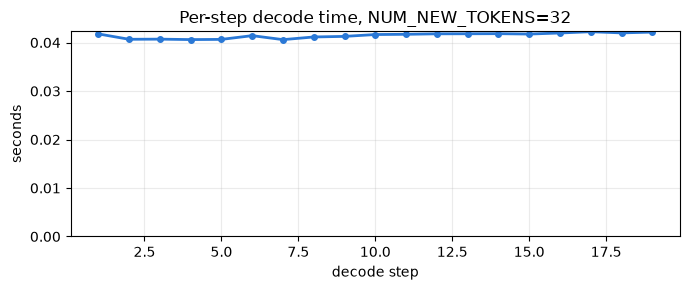

In [12]:
import matplotlib.pyplot as plt

mean_decode = sum(trace.decode_seconds()) / max(len(trace.steps), 1)
print(f"prefill ({PROMPT_LEN} tokens, one pass): {trace.prefill_seconds:.3f} s")
print(f"mean decode step (1 token):             {mean_decode:.4f} s")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(
    [s["step"] for s in trace.steps], trace.decode_seconds(),
    color="#2a78d6", linewidth=2, marker="o", markersize=4,
)
ax.set_xlabel("decode step")
ax.set_ylabel("seconds")
ax.set_title(f"Per-step decode time, NUM_NEW_TOKENS={NUM_NEW_TOKENS}")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Second length

If you have only run one value: go back to the **PARAMETER** cell, set
`NUM_NEW_TOKENS = 32`, and rerun from there down. Then run the summary
cell below.

## Summary

Reads the saved result files and reports every check. All must pass
before the task review.

In [13]:
from datetime import datetime, timezone

trace_data = json.loads((RESULTS / "03_decode_trace.json").read_text())
match_data = json.loads((RESULTS / "03_match_vs_generate.json").read_text())

CHECKS = {
    "module_import_ok": callable(greedy_decode),
    "prompt_len_24": PROMPT_LEN == 24,
    "prefill_cache_shape_ok": kv_shape(prefill_out.past_key_values) == (1, 8, PROMPT_LEN, 128),
    "cache_grew_one_per_step": all(
        run["kv_lens"] == list(range(run["prompt_len"] + 1, run["prompt_len"] + run["generated"]))
        for run in trace_data.values()
    ),
    "final_kv_len_formula_ok": all(
        run["final_kv_len"] == run["prompt_len"] + run["generated"] - 1
        for run in trace_data.values()
    ),
    "tokens_match_generate": bool(match_data) and all(run["match"] for run in match_data.values()),
    "two_lengths_saved": {"16", "32"} <= set(trace_data),
}
for name, ok in CHECKS.items():
    print(("PASS" if ok else "FAIL"), name)
assert all(CHECKS.values()), (
    "Some checks failed. If two_lengths_saved failed: set NUM_NEW_TOKENS to the "
    "missing value, rerun from the PARAMETER cell down, then rerun this cell."
)

summary = {
    "task": 3,
    "checks": CHECKS,
    "artifacts": [
        "results/03_decode_trace.json",
        "results/03_match_vs_generate.json",
    ],
    "written_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
(RESULTS / "03_summary.json").write_text(json.dumps(summary, indent=2))
print("\nAll checks pass. Saved results/03_summary.json")
print("Also run in a terminal:  uv run pytest tests/test_manual_decode.py -q")

PASS module_import_ok
PASS prompt_len_24
PASS prefill_cache_shape_ok
PASS cache_grew_one_per_step
PASS final_kv_len_formula_ok
PASS tokens_match_generate
PASS two_lengths_saved

All checks pass. Saved results/03_summary.json
Also run in a terminal:  uv run pytest tests/test_manual_decode.py -q
